#Object detection system for ambulance detection using the **EVD dataset** and the **Kaggle ambulance dataset**.

## 1. Environment Setup

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 6.8 MB/s eta 0:00:00


In [ ]:
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU: Tesla T4


## 2. EVD Dataset Preparation

In [ ]:
!unzip -q EVD.v1i.yolov11.zip -d /content/EVD

replace /content/EVD/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
from pathlib import Path

data_path = Path("/content/EVD/data.yaml")

print("Data YAML exists:", data_path.exists())
print("\n--- data.yaml ---")
print(data_path.read_text())

Data YAML exists: True

--- data.yaml ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['ambulance']

roboflow:
  workspace: sarah-hajaji
  project: evd-8lhfy
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/sarah-hajaji/evd-8lhfy/dataset/1


### Train Baseline Model on EVD

We first train YOLO11s on the original EVD dataset to establish a baseline before introducing the additional Kaggle data.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/EVD/data.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    patience=30,

    # Augmentation
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,

    # Lighting variations
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,

    project="/content/runs",
    name="ambulance_yolo11s",
    exist_ok=True
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EVD/data.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=tor

### Baseline Evaluation

The baseline model is evaluated on the EVD test set using mAP50, mAP50-95, Precision, and Recall.

In [ ]:
metrics = model.val(
    data="/content/EVD/data.yaml",
    split="test"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1491.7±401.9 MB/s, size: 47.0 KB)
val: Scanning /content/EVD/test/labels... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.1Kit/s 0.0s
val: New cache created: /content/EVD/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.2it/s 0.2s
                   all         10         15      0.988      0.933      0.945      0.779
Speed: 0.4ms preprocess, 12.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.9447826086956522
mAP50-95: 0.7785714843127887
Precision: 0.987871796035308
Recall: 0.9333333333333333


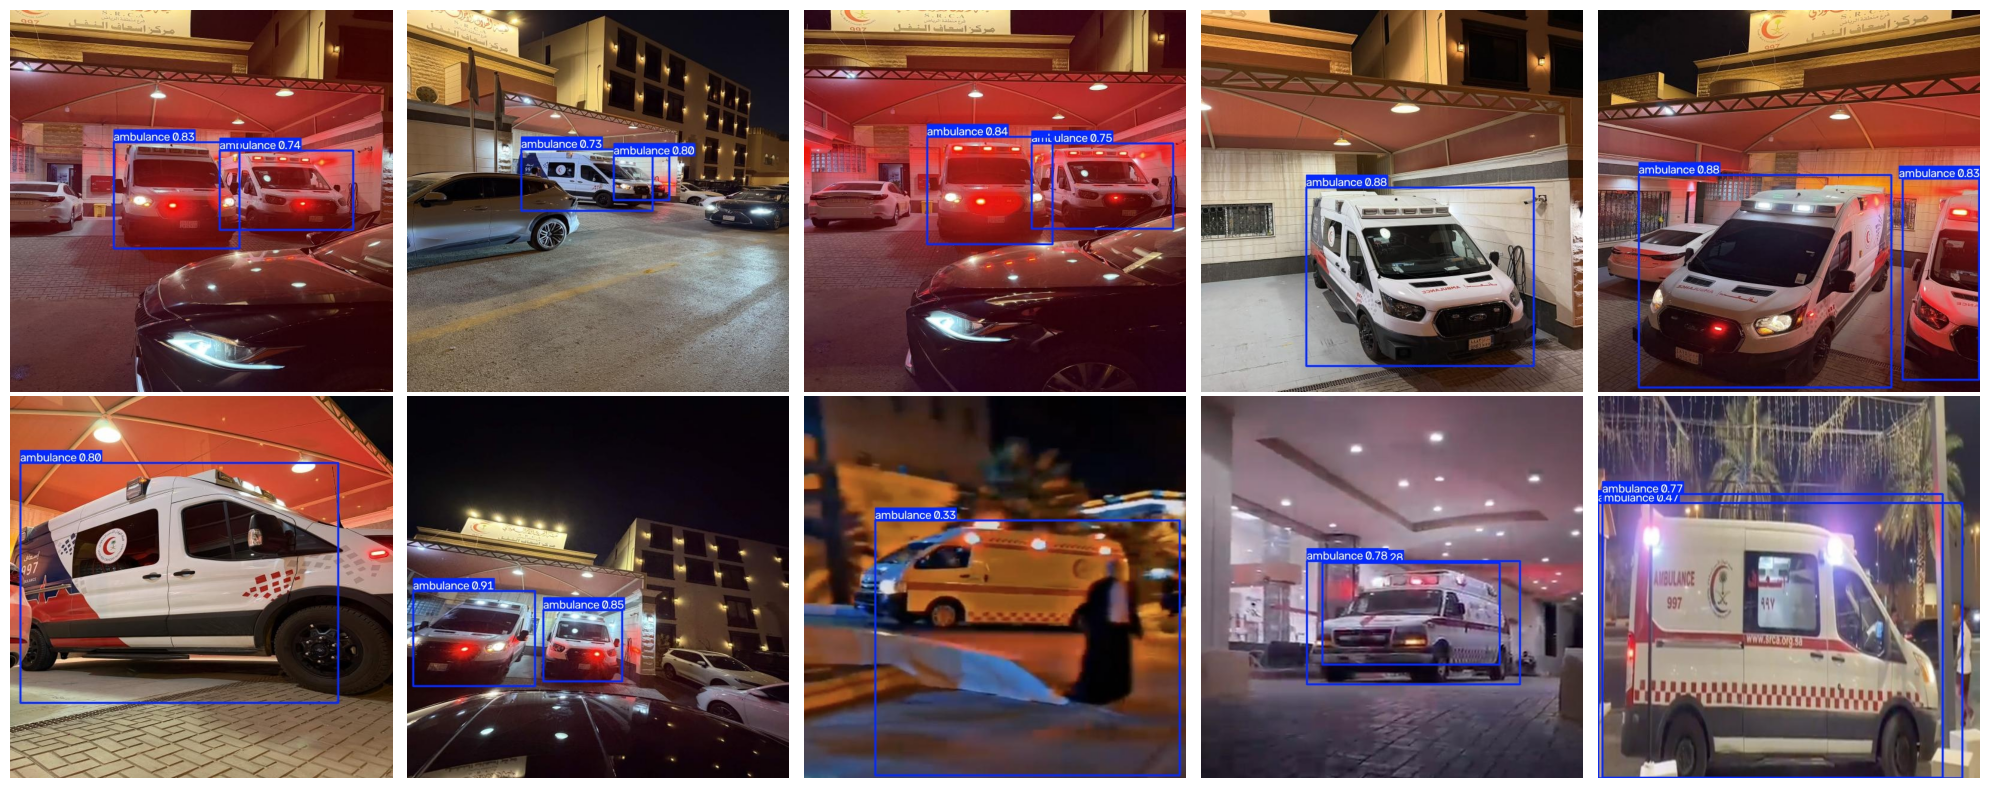

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/content/runs/detect/predict")
images = sorted(results_dir.glob("*.jpg"))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, img_path in zip(axes.flat, images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Kaggle Dataset Preparation

In [ ]:
import kagglehub

path = kagglehub.dataset_download("musawerhussain/rand-amb-dataset")

print("Dataset path:", path)

100%|██████████| 105M/105M [00:01<00:00, 78.8MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/musawerhussain/rand-amb-dataset/versions/1


### Inspect Label Formats

The Kaggle dataset contains a mixture of YOLO detection and segmentation-style labels. We inspect the labels before cleaning them.

In [ ]:
from pathlib import Path

labels_dir = Path(
    "/root/.cache/kagglehub/datasets/"
    "musawerhussain/rand-amb-dataset/versions/1/test/labels"
)

detection = 0
segmentation = 0
empty = 0
mixed = 0

for file in labels_dir.glob("*.txt"):
    lines = [x.strip() for x in file.read_text().splitlines() if x.strip()]

    if not lines:
        empty += 1
        continue

    lengths = {len(line.split()) for line in lines}

    if lengths == {5}:
        detection += 1
    elif all(n > 5 for n in lengths):
        segmentation += 1
    else:
        mixed += 1

print("Detection:", detection)
print("Segmentation:", segmentation)
print("Mixed:", mixed)
print("Empty:", empty)

Detection: 79
Segmentation: 5
Mixed: 2
Empty: 0


### Create a Clean Kaggle Copy

In [ ]:
from pathlib import Path
import shutil

src = Path(
    "/root/.cache/kagglehub/datasets/"
    "musawerhussain/rand-amb-dataset/versions/1"
)

clean = Path("/content/Kaggle_clean")

#Copy from kaggle
if clean.exists():
    shutil.rmtree(clean)

shutil.copytree(src, clean)

print("Created:", clean)

Created: /content/Kaggle_clean


###Clean Kaggle Test Labels

Only valid YOLO detection rows containing:

`class + x_center + y_center + width + height`

are retained. Images without a valid detection label are removed.

In [ ]:
from pathlib import Path
import shutil

test_images = clean / "test" / "images"
test_labels = clean / "test" / "labels"

removed_images = 0
removed_labels = 0

for label_file in test_labels.glob("*.txt"):
    lines = [
        line.strip()
        for line in label_file.read_text().splitlines()
        if line.strip()
    ]


    detection_lines = [
        line for line in lines
        if len(line.split()) == 5
    ]

    if detection_lines:
        label_file.write_text("\n".join(detection_lines) + "\n")
    else:

        label_file.unlink()
        removed_labels += 1


        stem = label_file.stem

        for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
            image_file = test_images / f"{stem}{ext}"
            if image_file.exists():
                image_file.unlink()
                removed_images += 1
                break

print("Cleaning complete!")
print("Removed labels:", removed_labels)
print("Removed images:", removed_images)

Cleaning complete!
Removed labels: 5
Removed images: 5


### Verify Dataset Counts

In [ ]:
from pathlib import Path

EVD = Path("/content/EVD")
KAGGLE = Path("/content/Kaggle_clean")

for name, path in [("EVD", EVD), ("Kaggle", KAGGLE)]:
    print(f"\n{name}")
    for split in ["train", "valid", "test"]:
        images = list((path / split / "images").glob("*"))
        labels = list((path / split / "labels").glob("*.txt"))
        print(f"{split}: {len(images)} images | {len(labels)} labels")


EVD
train: 144 images | 144 labels
valid: 21 images | 21 labels
test: 10 images | 10 labels

Kaggle
train: 1782 images | 1782 labels
valid: 168 images | 168 labels
test: 81 images | 81 labels


## Combine EVD and Kaggle Datasets
Build the Combined Dataset

In [ ]:
from pathlib import Path
import shutil

combined = Path("/content/Combined_EVD_Kaggle")


if combined.exists():
    shutil.rmtree(combined)


for split in ["train", "valid", "test"]:
    (combined / split / "images").mkdir(parents=True)
    (combined / split / "labels").mkdir(parents=True)


def copy_dataset(dataset_path, prefix):
    dataset_path = Path(dataset_path)

    for split in ["train", "valid", "test"]:
        src_images = dataset_path / split / "images"
        src_labels = dataset_path / split / "labels"

        dst_images = combined / split / "images"
        dst_labels = combined / split / "labels"

        for img in src_images.iterdir():
            if img.is_file():
                shutil.copy2(
                    img,
                    dst_images / f"{prefix}_{img.name}"
                )

        for label in src_labels.glob("*.txt"):
            shutil.copy2(
                label,
                dst_labels / f"{prefix}_{label.name}"
            )



copy_dataset(EVD, "evd")

copy_dataset(KAGGLE, "kaggle")

print("Combined dataset created successfully!")

Combined dataset created successfully!


### Create the Combined Dataset Configuration

In [ ]:
from pathlib import Path

yaml_content = """
train: /content/Combined_EVD_Kaggle/train/images
val: /content/Combined_EVD_Kaggle/valid/images
test: /content/Combined_EVD_Kaggle/test/images

nc: 1
names: ['ambulance']
"""

yaml_path = Path("/content/Combined_EVD_Kaggle/data.yaml")
yaml_path.write_text(yaml_content.strip())

print(yaml_path)
print("\n--- data.yaml ---")
print(yaml_path.read_text())

/content/Combined_EVD_Kaggle/data.yaml

--- data.yaml ---
train: /content/Combined_EVD_Kaggle/train/images
val: /content/Combined_EVD_Kaggle/valid/images
test: /content/Combined_EVD_Kaggle/test/images

nc: 1
names: ['ambulance']


##Train YOLO11s on the Combined Dataset

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/Combined_EVD_Kaggle/data.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    patience=30,

    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,

    project="/content/runs",
    name="ambulance_combined_yolo11s",
    exist_ok=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Combined_EVD_Kaggle/data.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ambulance_combined_yolo11

### Evaluate the Combined Model

This evaluation provides the baseline performance of the model trained on the combined dataset, before fine-tuning.

In [ ]:
from ultralytics import YOLO


model = YOLO(
    "/content/runs/ambulance_combined_yolo11s/weights/best.pt"
)

# Combined Test
results = model.val(
    data="/content/Combined_EVD_Kaggle/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    project="/content/runs",
    name="final_test"
)

print("===== FINAL TEST RESULTS =====")
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.0±8.9 MB/s, size: 45.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/Combined_EVD_Kaggle/test/labels... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 573.1it/s 0.2s
val: New cache created: /content/Combined_EVD_Kaggle/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.2s
                   all         91        149      0.857      0.644      0.706        0.4
Speed: 5.5ms preprocess, 9.8ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/final_test
===== FINAL TEST RESULTS =====
mAP50: 0.7064174025556

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from pathlib import Path
import math

result_dir = Path("/content/runs/final_test_predictions")

pred_images = [
    p for p in result_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

cols = 4
rows = math.ceil(len(pred_images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for ax, img_path in zip(axes, pred_images):
    img = PILImage.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:25])

for ax in axes[len(pred_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, img_path in zip(axes, failed):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name[:25])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Evaluate the Combined Model on the EVD Test Set

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_combined_yolo11s/weights/best.pt"
)

evd_results = model.val(
    data="/content/EVD/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    project="/content/runs",
    name="final_evd_test"
)

print("===== FINAL MODEL ON EVD TEST =====")
print("mAP50:", evd_results.box.map50)
print("mAP50-95:", evd_results.box.map)
print("Precision:", evd_results.box.mp)
print("Recall:", evd_results.box.mr)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1184.2±740.6 MB/s, size: 47.3 KB)
val: Scanning /content/EVD/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.1it/s 0.2s
                   all         10         15      0.929      0.933      0.969       0.76
Speed: 0.4ms preprocess, 13.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/final_evd_test
===== FINAL MODEL ON EVD TEST =====
mAP50: 0.969463768115942
mAP50-95: 0.7601876152832675
Precision: 0.929099110720829
Recall: 0.9333333333333333


## Final Fine-tuning
The best model from combined-dataset training is fine-tuned for 40 additional epochs with a lower learning rate and adjusted augmentation settings.

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_combined_yolo11s/weights/best.pt"
)

results = model.train(
    data="/content/Combined_EVD_Kaggle/data.yaml",

    epochs=40,
    imgsz=640,
    batch=16,

    lr0=0.0005,
    lrf=0.01,

    degrees=8,
    translate=0.15,
    scale=0.6,
    shear=2,
    perspective=0.0005,
    fliplr=0.5,

    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.5,

    mosaic=1.0,
    mixup=0.15,

    patience=15,

    project="/content/runs",
    name="ambulance_final_finetune",
    exist_ok=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Combined_EVD_Kaggle/data.yaml, degrees=8, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/content/runs/ambulance_combined_yolo11s/weights/best.pt, momentum=0.937, mosaic=1.0, 

## Final Model Evaluation

 Combined Test

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_final_finetune/weights/best.pt"
)

results = model.val(
    data="/content/Combined_EVD_Kaggle/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    project="/content/runs",
    name="finetune_test"
)

print("===== FINETUNED TEST =====")
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1192.2±185.2 MB/s, size: 45.5 KB)
val: Scanning /content/Combined_EVD_Kaggle/test/labels.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 38.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.1s
                   all         91        149      0.882      0.664      0.724      0.427
Speed: 6.5ms preprocess, 9.9ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /content/runs/finetune_test
===== FINETUNED TEST =====
mAP50: 0.7243597367894244
mAP50-95: 0.42660690748881713
Precision: 0.8817234119930114
Recall: 0.6644295302013423


EVD Test

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_final_finetune/weights/best.pt"
)

evd_results = model.val(
    data="/content/EVD/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    project="/content/runs",
    name="finetune_evd_test"
)

print("===== FINETUNED MODEL — EVD TEST =====")
print("mAP50:", evd_results.box.map50)
print("mAP50-95:", evd_results.box.map)
print("Precision:", evd_results.box.mp)
print("Recall:", evd_results.box.mr)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1149.7±529.5 MB/s, size: 56.5 KB)
val: Scanning /content/EVD/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.1it/s 0.2s
                   all         10         15      0.931          1      0.991      0.806
Speed: 0.4ms preprocess, 12.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/finetune_evd_test
===== FINETUNED MODEL — EVD TEST =====
mAP50: 0.99125
mAP50-95: 0.8060643939393939
Precision: 0.9312509638701124
Recall: 1.0


## Final Results

### Fine-tuned YOLO11s

| Test Set | mAP50 | mAP50-95 | Precision | Recall |
|---|---:|---:|---:|---:|
| Combined Test | **72.4%** | **42.7%** | **88.2%** | **66.4%** |
| EVD Test | **99.1%** | **80.6%** | **93.1%** | **100%** |

## Video Demo

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_final_finetune/weights/best.pt"
)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving EVD video.mp4 to EVD video.mp4


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/ambulance_final_finetune/weights/best.pt"
)

results = model.predict(
    source="/content/EVD video.mp4",
    conf=0.25,
    imgsz=640,
    save=True,
    stream=True,
    project="/content/runs",
    name="EVD_video_test"
)

for _ in results:
    pass

print("Done!")


video 1/1 (frame 1/621) /content/EVD video.mp4: 384x640 1 ambulance, 10.9ms
video 1/1 (frame 2/621) /content/EVD video.mp4: 384x640 1 ambulance, 14.1ms
video 1/1 (frame 3/621) /content/EVD video.mp4: 384x640 1 ambulance, 13.6ms
video 1/1 (frame 4/621) /content/EVD video.mp4: 384x640 1 ambulance, 13.9ms
video 1/1 (frame 5/621) /content/EVD video.mp4: 384x640 (no detections), 13.3ms
video 1/1 (frame 6/621) /content/EVD video.mp4: 384x640 1 ambulance, 13.6ms
video 1/1 (frame 7/621) /content/EVD video.mp4: 384x640 (no detections), 12.3ms
video 1/1 (frame 8/621) /content/EVD video.mp4: 384x640 (no detections), 13.2ms
video 1/1 (frame 9/621) /content/EVD video.mp4: 384x640 (no detections), 13.0ms
video 1/1 (frame 10/621) /content/EVD video.mp4: 384x640 (no detections), 13.4ms
video 1/1 (frame 11/621) /content/EVD video.mp4: 384x640 (no detections), 13.7ms
video 1/1 (frame 12/621) /content/EVD video.mp4: 384x640 (no detections), 18.7ms
video 1/1 (frame 13/621) /content/EVD video.mp4: 384x640

In [ ]:
!ffmpeg -y -i "/content/runs/EVD_video_test/EVD video.avi" \
"/content/EVD_video_result.mp4"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import Video

Video(
    "/content/EVD_video_result.mp4",
    embed=True,
    width=900
)